<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/tarefa13Completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 13 — Normal, t de Student, qui-quadrado e F de Fisher

**Integrantes:**

- Drielly Mathias Albertti — nº 16831084
- Kawana Ganeo de Carvalho — nº 14669691
- Melyssa Ponce Lopes — nº 16831017

---


**Fonte da base:** UCI Machine Learning Repository – Iris Dataset             
**Link:** https://archive.ics.uci.edu/dataset/53/iris                       
**Instituição responsável pelo repositório:** University of California, Irvine (UCI)  
**Autor associado à base:** R. A. Fisher

As **variáveis quantitativas** da base correspondem as medidas morfológicas das plantas, expressas em cm: comprimento da sépala, largura da sépala, comprimento da pétala e largura da pétala.





##1. Normal
A distribuição Normal é uma distribuição contínua caracterizada por uma curva simétrica em torno de sua média.  

**Função:**

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right]
$$

em que:

* \(x\) representa um possível valor da variável contínua;
* (μ) representa a média da distribuição;
* (σ) representa o desvio-padrão, com (σ>0);
* (σ^2) representa a variância;
* (π) é a constante matemática pi;
* (e) é a base dos logaritmos naturais.

Na implementação da SciPy, a distribuição Normal é representada por `scipy.stats.norm`, sendo **loc** utilizado para representar a média e **scale** para representar o desvio-padrão. E as funções como **pdf**, **cdf**, **sf** e **ppf** representam, respectivamente, densidade, probabilidade acumulada, probabilidade na cauda superior e quantis.

**Referências:** SciPy Documentation – `scipy.stats.norm`;  
 NIST/SEMATECH e-Handbook of Statistical Methods.

A distribuição Normal será utilizada como modelo para uma característica morfológica contínua das plantas da base Iris. Será utilizado o **comprimento da sépala das 50 plantas de *Iris setosa***.

Nesse caso, o comprimento da sépala é uma medida obtida diretamente de um organismo. Já a distribuição Normal é um modelo estatístico utilizado para representar a distribuição desses valores.

A partir das 50 observações de *Iris setosa*, serão estimados a média e o desvio-padrão, que serão utilizados como parâmetros do modelo Normal.  



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
import pandas as pd

# Baixando a base diretamente do repositório oficial da UCI para evitar erros de arquivo ausente
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Ordem correta das colunas do Iris original:
# 1. sepal length, 2. sepal width, 3. petal length, 4. petal width
colunas = [
    "Comprimento da sépala",
    "Largura da sépala",
    "Comprimento da pétala",
    "Largura da pétala",
    "Espécies"
]

iris = pd.read_csv(
    url,
    header=None,
    names=colunas
)

iris.head()

,Comprimento da sépala,Largura da sépala,Comprimento da pétala,Largura da pétala,Espécies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


###1.1 Curvas:

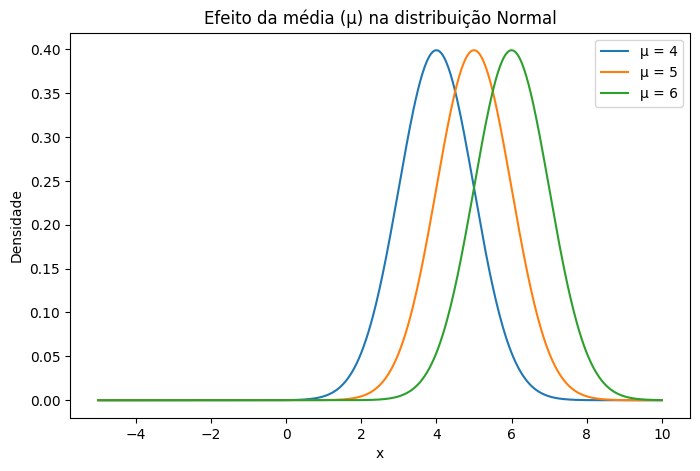

In [ ]:
x = np.linspace(-5, 10, 500)

plt.figure(figsize=(8, 5))

for mu in [4, 5, 6]:
    y = stats.norm.pdf(x, loc=mu, scale=1)
    plt.plot(x, y, label=f"μ = {mu}")

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Efeito da média (μ) na distribuição Normal")
plt.legend()
plt.show()

Mantendo o desvio-padrão constante, o aumento da média desloca toda a curva horizontalmente para a direita, enquanto a diminuição da média desloca a curva para a esquerda. A forma e a dispersão da curva permanecem iguais.

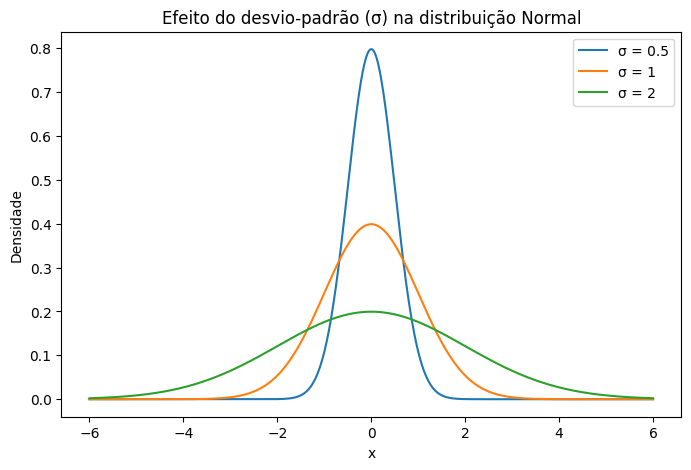

In [ ]:
x = np.linspace(-6, 6, 500)

plt.figure(figsize=(8, 5))

for sigma in [0.5, 1, 2]:
    y = stats.norm.pdf(x, loc=0, scale=sigma)
    plt.plot(x, y, label=f"σ = {sigma}")

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Efeito do desvio-padrão (σ) na distribuição Normal")
plt.legend()
plt.show()

Mantendo a média constante, valores maiores de \(σ) aumentam a dispersão dos valores em torno da média. A curva fica mais larga e seu pico diminui. Valores menores de (σ) produzem uma curva mais concentrada e com pico mais elevado. A distribuição Normal permanece simétrica.

A utilização da distribuição Normal exige que a variável seja contínua e que a aproximação pela curva Normal seja biologicamente e estatisticamente razoável.

Uma limitação importante é que a base possui somente 50 observações de cada espécie. Além disso, as plantas presentes na base não devem ser consideradas como uma amostra representativa de todas as plantas das respectivas espécies. Dessa forma, as probabilidades calculadas representam o modelo ajustado aos dados disponíveis e não uma estimativa universal para a espécie.

##2. t de Student
A distribuição t de Student é uma distribuição contínua utilizada em situações envolvendo estatísticas padronizadas relacionadas à média, especialmente quando a variância populacional é desconhecida.

**Função:**

$$
f(t)=
\frac{\Gamma\left(\frac{\nu+1}{2}\right)}
{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)}
\left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

em que:

* (t) representa um valor da estatística t;
* (ν) representa os graus de liberdade;
* (Γ) representa a função gama;
* (ν>0).

Diferentemente do comprimento da sépala, que é uma medida biológica, o valor de \(t\) é uma **estatística calculada a partir de uma ou mais amostras**.

Na SciPy, a distribuição é implementada por `scipy.stats.t`, sendo os graus de liberdade especificados pelo parâmetro **df**.

**Referências:** SciPy Documentation – `scipy.stats.t`;  
NIST/SEMATECH e-Handbook of Statistical Methods.



**Exemplo:**
- *Iris setosa:* 50 plantas
- *Iris versicolor:* 50 plantas
- Variável: Comprimento da sépala  

$$
t = \frac{\bar{X}_1-\bar{X}_2}
{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}}
$$

Os graus de liberdade são estimados pela aproximação de **Welch-Satterthwaite**.

Assim, o que terá distribuição t sob as condições do modelo é a estatística padronizada, e não os comprimentos individuais.

###2.1 Curva:

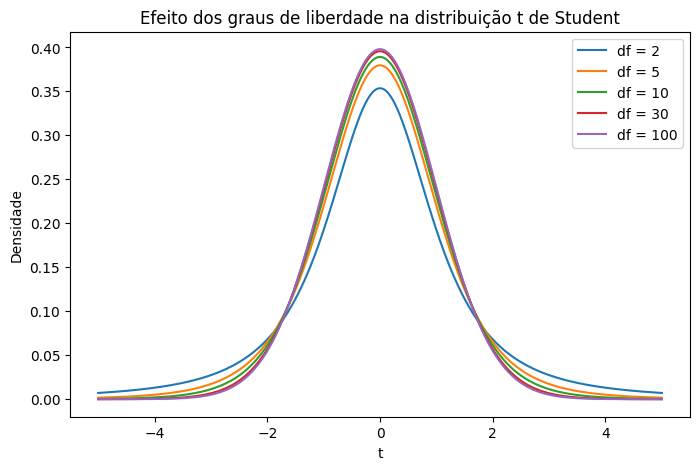

In [ ]:
x = np.linspace(-5, 5, 500)

plt.figure(figsize=(8, 5))

for df in [2, 5, 10, 30, 100]:
    y = stats.t.pdf(x, df=df)
    plt.plot(x, y, label=f"df = {df}")

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade na distribuição t de Student")
plt.legend()
plt.show()

Com poucos graus de liberdade, a distribuição t apresenta caudas mais pesadas e maior dispersão do que a Normal padrão. À medida que os graus de liberdade aumentam, as caudas ficam menos pesadas e a distribuição se aproxima progressivamente da distribuição Normal padrão.

A utilização da distribuição t depende das condições associadas à estatística utilizada. Como estamos utilizando duas espécies diferentes, cada planta pertence a apenas um dos grupos. A aproximação de Welch permite trabalhar sem assumir igualdade entre as variâncias.

Uma limitação é que as observações da base Iris correspondem a um conjunto específico de plantas e não necessariamente constituem uma amostra aleatória de toda a população das espécies. Portanto, a análise deve ser interpretada no contexto da base utilizada.



##3. Qui-quadrado
A distribuição qui-quadrado é uma distribuição contínua definida para valores não negativos e caracterizada pelos graus de liberdade.

**Função:**

$$
f(x)=
\frac{1}{2^{\nu/2}\Gamma(\nu/2)}
x^{\nu/2-1}e^{-x/2},
\qquad x>0
$$

em que:

* \(x\) representa um valor da estatística qui-quadrado;
* \(ν) representa os graus de liberdade;
* \(Γ) representa a função gama;
* \(e\) é a base dos logaritmos naturais;
* \(ν>0\).

Na SciPy, essa distribuição é implementada por `scipy.stats.chi2`.

**Referências:** SciPy Documentation – scipy.stats.chi2;  
NIST/SEMATECH e-Handbook of Statistical Methods.

Para uma amostra proveniente de uma população Normal, a estatística associada à variância pode ser expressa como:

$$
\chi^2=\frac{(n-1)S^2}{\sigma_0^2}
$$

com \(ν=n-1\) graus de liberdade.

Em que:
- \(S^2\) = variância calculada a partir das plantas;
- \(n\) = número de plantas;
- \(σ_0^2) = variância de referência;
- \(χ^2\) = estatística resultante.

**Exemplo:**

A medida biológica continua sendo o comprimento da sépala. A quantidade que será relacionada à distribuição qui-quadrado é uma estatística calculada a partir da variância amostral dos comprimentos.

O principal parâmetro é:

$$ \nu = n-1 $$

Para as 50 *Iris setosa*:

ν=50−1=49


###3.1 Curva:

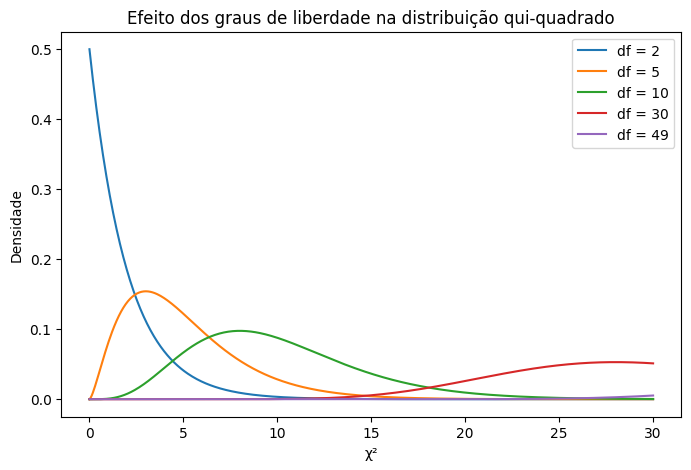

In [ ]:
x = np.linspace(0, 30, 500)

plt.figure(figsize=(8, 5))

for df in [2, 5, 10, 30, 49]:
    y = stats.chi2.pdf(x, df=df)
    plt.plot(x, y, label=f"df = {df}")

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade na distribuição qui-quadrado")
plt.legend()
plt.show()

Com poucos graus de liberdade, a distribuição qui-quadrado apresenta forte assimetria à direita. Conforme os graus de liberdade aumentam, a assimetria diminui e a distribuição se torna mais concentrada em torno de valores maiores. A distribuição permanece definida apenas para valores iguais ou superiores a zero.

##4. F de Fisher
A distribuição F de Fisher é uma distribuição contínua utilizada para representar razões entre duas quantidades relacionadas a variâncias. Sua função densidade pode ser escrita como:

$$
f(x)=
\frac{
\left(\frac{\nu_1}{\nu_2}\right)^{\nu_1/2}
x^{\nu_1/2-1}
}{
B\left(\frac{\nu_1}{2},\frac{\nu_2}{2}\right)
\left(1+\frac{\nu_1}{\nu_2}x\right)^{(\nu_1+\nu_2)/2}
},
\qquad x>0
$$

em que:

* \(x\) representa um valor da estatística F;
* \(ν_1\) representa os graus de liberdade do numerador;
* \(ν_2\) representa os graus de liberdade do denominador;
* \(B\) representa a função beta;
* \(\v_1>0\) e \(v_2>0\).

No contexto deste trabalho, a estatística F será construída como uma razão entre duas variâncias amostrais:

$$
F=\frac{S_1^2}{S_2^2}
$$

Na SciPy, a distribuição é implementada por `scipy.stats.f`, sendo **dfn** os graus de liberdade do numerador e **dfd** os graus de liberdade do denominador.

**Referências:** SciPy Documentation – `scipy.stats.f`;  
NIST/SEMATECH e-Handbook of Statistical Methods.

**Exemplo:**
A variabilidade do comprimento da sépala difere entre *Iris setosa* e *Iris virginica*?

A variável é a mesma, mas temos dois grupos independentes, com cada um possuindo 50 observações individuais.

A estatística será:

$$ F=\frac{S_{\text{virginica}}^2}{S_{\text{setosa}}^2} $$

Então:

$$ \nu_1=50-1=49 $$
$$ \nu_2=50-1=49 $$

###4.1 Curvas:

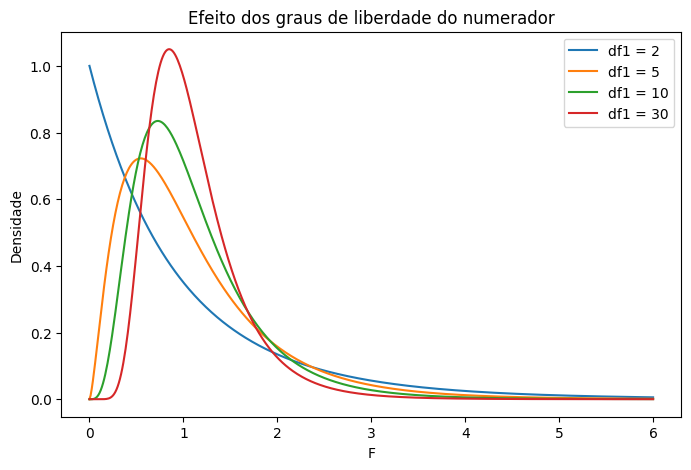

In [ ]:
#Variando o grau de liberdade do numerador
x = np.linspace(0, 6, 500)

plt.figure(figsize=(8, 5))

for df1 in [2, 5, 10, 30]:
    y = stats.f.pdf(x, dfn=df1, dfd=20)
    plt.plot(x, y, label=f"df1 = {df1}")

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade do numerador")
plt.legend()
plt.show()

Mantendo os graus de liberdade do denominador constantes, a alteração de \(v_1\) modifica a forma da distribuição, principalmente sua assimetria e concentração. Com poucos graus de liberdade, a distribuição apresenta maior assimetria e uma cauda direita mais pronunciada. Com o aumento de \(v_1\), a distribuição tende a ficar mais concentrada.

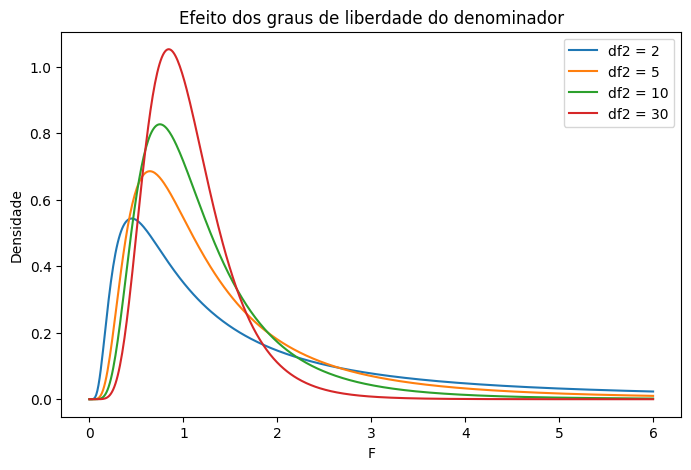

In [ ]:
#Variando o grau de liberdade do denominador
x = np.linspace(0, 6, 500)

plt.figure(figsize=(8, 5))

for df2 in [2, 5, 10, 30]:
    y = stats.f.pdf(x, dfn=20, dfd=df2)
    plt.plot(x, y, label=f"df2 = {df2}")

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade do denominador")
plt.legend()
plt.show()

Mantendo os graus de liberdade do numerador constantes, a alteração de \(v_2\) também modifica a assimetria e a cauda direita da distribuição. Valores pequenos de \(v_2\) produzem maior dispersão na razão de variâncias, enquanto valores maiores tornam a distribuição mais concentrada.

A utilização da distribuição F para uma razão de variâncias pressupõe que as duas amostras sejam independentes e que as observações de cada grupo sejam provenientes de populações aproximadamente Normais.  

Uma limitação é que a razão de variâncias depende da ordem escolhida para numerador e denominador. Por isso, essa escolha deve ser informada explicitamente. Neste trabalho, será utilizada a variância do comprimento da sépala de *Iris virginica* no numerador e a de *Iris setosa* no denominador.

A distribuição F, portanto, não descreve os comprimentos das sépalas diretamente. Ela descreve o comportamento teórico de uma razão de variâncias amostrais sob determinadas condições estatísticas.

##5. Probabilidades
### 5.1 Probabilidades para a distribuição Normal
Será considerado o comprimento da sépala das 50 plantas de *Iris setosa*. A variável é uma medida morfológica contínua, expressa em centímetros, e será modelada por uma distribuição Normal com média de 5,006 cm e desvio-padrão de 0,3525 cm.
####5.1.1 Probabilidade acumulada


**Pergunta biológica:** Qual a probabilidade de uma *Iris setosa* apresentar comprimento da sépala menor ou igual a 5,5 cm?

In [ ]:
import pandas as pd
from scipy import stats

# Carregando os dados para garantir que a variável 'iris' esteja definida no kernel
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = [
    "Comprimento da sépala",
    "Largura da sépala",
    "Comprimento da pétala",
    "Largura da pétala",
    "Espécies"
]
iris = pd.read_csv(url, header=None, names=colunas)

# Filtrando o comprimento da sépala apenas para a espécie Iris-setosa
setosa_sepal_length = iris[iris['Espécies'] == 'Iris-setosa']['Comprimento da sépala']

# Estimando os parâmetros da distribuição Normal (média e desvio-padrão)
media = setosa_sepal_length.mean()
desvio = setosa_sepal_length.std(ddof=1)

# Calculando a probabilidade acumulada para X <= 5.5 cm
prob_acumulada = stats.norm.cdf(
    5.5,
    loc=media,
    scale=desvio
)

print(f"Média estimada = {media:.4f} cm")
print(f"Desvio-padrão estimado = {desvio:.4f} cm")
print(f"P(X ≤ 5,5) = {prob_acumulada:.4f}")
print(f"Probabilidade = {prob_acumulada*100:.2f}%")

Média estimada = 5.0060 cm
Desvio-padrão estimado = 0.3525 cm
P(X ≤ 5,5) = 0.9195
Probabilidade = 91.95%


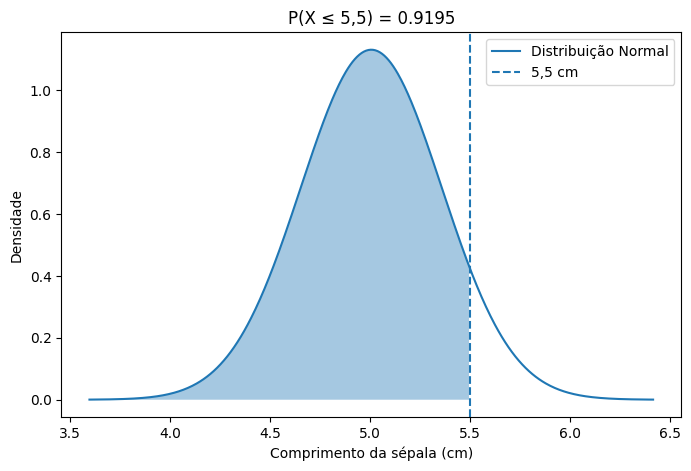

In [ ]:
x = np.linspace(media - 4*desvio, media + 4*desvio, 500)
y = stats.norm.pdf(x, loc=media, scale=desvio)

limite = 5.5
x_sombra = x[x <= limite]
y_sombra = stats.norm.pdf(x_sombra, loc=media, scale=desvio)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Normal")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="5,5 cm"
)

plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Densidade")
plt.title(f"P(X ≤ 5,5) = {prob_acumulada:.4f}")
plt.legend()
plt.show()

A área sombreada corresponde à probabilidade acumulada calculada pela função **cdf**. O resultado numérico de aproximadamente 0,9195 corresponde a uma área de aproximadamente 91,95% sob a curva à esquerda de 5,5 cm.

Assim, sob o modelo Normal ajustado aos dados, estima-se uma probabilidade de aproximadamente 91,95% de uma medida de comprimento da sépala de *Iris setosa* ser menor ou igual a 5,5 cm.

####5.1.2 Probabilidade entre dois valores

**Pergunta biológica:** Qual a probabilidade do comprimento da sépala estar entre 4,8 e 5,3 cm?

P(4,8<X<5,3) = P(X<5,3)−P(X<4,8)

In [ ]:
from scipy import stats

limite_inferior = 4.8
limite_superior = 5.3

prob_intervalo = (
    stats.norm.cdf(limite_superior, loc=media, scale=desvio)
    - stats.norm.cdf(limite_inferior, loc=media, scale=desvio)
)

print(f"P(4,8 < X < 5,3) = {prob_intervalo:.4f}")
print(f"Probabilidade = {prob_intervalo*100:.2f}%")

P(4,8 < X < 5,3) = 0.5184
Probabilidade = 51.84%


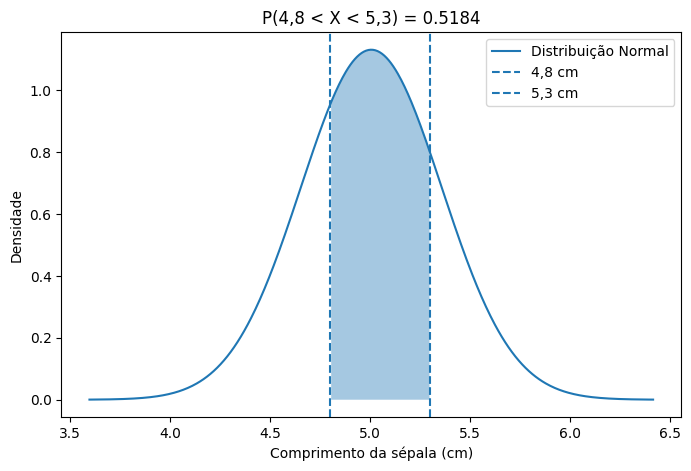

In [ ]:
x_sombra = x[
    (x >= limite_inferior) &
    (x <= limite_superior)
]

y_sombra = stats.norm.pdf(
    x_sombra,
    loc=media,
    scale=desvio
)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Normal")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite_inferior,
    linestyle="--",
    label="4,8 cm"
)

plt.axvline(
    limite_superior,
    linestyle="--",
    label="5,3 cm"
)

plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Densidade")
plt.title(f"P(4,8 < X < 5,3) = {prob_intervalo:.4f}")
plt.legend()
plt.show()

A região sombreada representa a área da distribuição Normal entre 4,8 e 5,3 cm. O valor calculado numericamente foi aproximadamente 0,5184, equivalente a 51,84%.

Portanto, sob o modelo Normal ajustado aos dados, a probabilidade de uma medida de comprimento da sépala estar entre 4,8 e 5,3 cm é de aproximadamente 51,84%.

####5.1.3 Probabilidade acima de um valor

**Pergunta biológica:** Qual a probabilidade do comprimento da sépala ser maior que 5,4 cm?

In [ ]:
limite = 5.4

prob_acima = stats.norm.sf(
    limite,
    loc=media,
    scale=desvio
)

print(f"P(X > 5,4) = {prob_acima:.4f}")
print(f"Probabilidade = {prob_acima*100:.2f}%")

P(X > 5,4) = 0.1318
Probabilidade = 13.18%


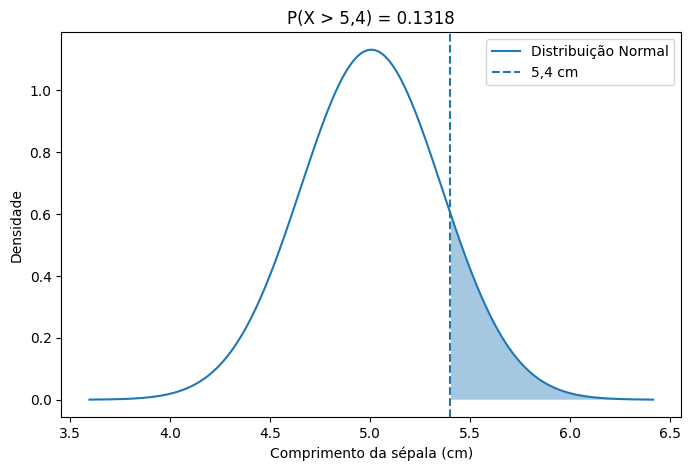

In [ ]:
x_sombra = x[x >= limite]
y_sombra = stats.norm.pdf(
    x_sombra,
    loc=media,
    scale=desvio
)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Normal")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="5,4 cm"
)

plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Densidade")
plt.title(f"P(X > 5,4) = {prob_acima:.4f}")
plt.legend()
plt.show()

A área sombreada corresponde à região da curva à direita de 5,4 cm. O resultado numérico foi aproximadamente 0,1318, equivalente a 13,18%.

Assim, sob o modelo Normal ajustado, a probabilidade de uma medida de comprimento da sépala de *Iris setosa* ser superior a 5,4 cm é de aproximadamente 13,18%.

####5.1.4 Percentil

**Pergunta biológica:** Qual comprimento da sépala corresponde ao 90º percentil das *Iris setosa* segundo o modelo Normal?

In [ ]:
percentil_90 = stats.norm.ppf(
    0.90,
    loc=media,
    scale=desvio
)

print(f"90º percentil = {percentil_90:.4f} cm")

90º percentil = 5.4577 cm


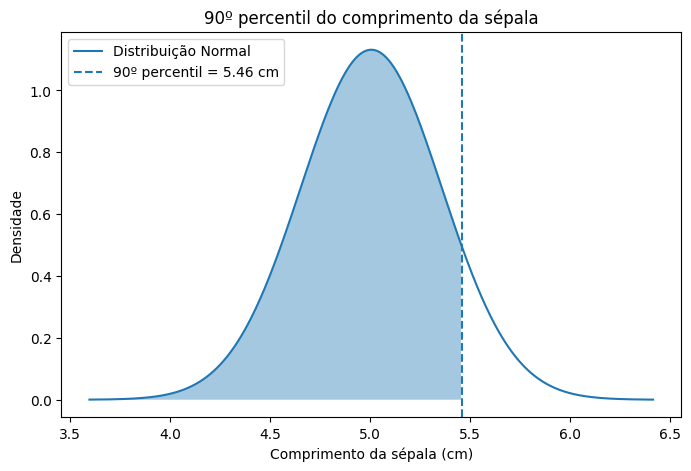

In [ ]:
x_sombra = x[x <= percentil_90]
y_sombra = stats.norm.pdf(
    x_sombra,
    loc=media,
    scale=desvio
)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Normal")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    percentil_90,
    linestyle="--",
    label=f"90º percentil = {percentil_90:.2f} cm"
)

plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Densidade")
plt.title("90º percentil do comprimento da sépala")
plt.legend()
plt.show()

O 90º percentil estimado pelo modelo Normal é aproximadamente 5,46 cm. Isso significa que, segundo o modelo ajustado, aproximadamente 90% dos comprimentos de sépala estão abaixo ou iguais a esse valor, enquanto aproximadamente 10% estão acima dele.

###5.2 Probabilidades para distribuição t de Student
Como as variâncias das duas espécies não são iguais, vamos utilizar o teste t de Welch, que não exige a hipótese de variâncias iguais.

**Os dados são:**
- *Iris setosa:* média = 5,006 cm, n = 50
- *Iris versicolor:* média = 5,936 cm, n = 50

**A diferença observada entre as médias é:** 5,006 - 5,936 = -0,930 cm

Ou seja, na amostra, a sépala da *Iris setosa* apresentou comprimento médio 0,93 cm menor que a da *Iris versicolor*.

**A estatística t é calculada por:** t = (x̄₁ - x̄₂) / √(s₁²/n₁ + s₂²/n₂)

**E os graus de liberdade são calculados pela aproximação de Welch:**

ν = (s₁²/n₁ + s₂²/n₂)² /
    [(s₁²/n₁)²/(n₁-1) + (s₂²/n₂)²/(n₂-1)]

In [ ]:
import pandas as pd
import numpy as np

# Carregando a base de dados para garantir que a variável 'iris' esteja definida no kernel
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = [
    "Comprimento da sépala",
    "Largura da sépala",
    "Comprimento da pétala",
    "Largura da pétala",
    "Espécies"
]
iris = pd.read_csv(url, header=None, names=colunas)

# Filtrando as espécies utilizando as colunas em português conforme seu DataFrame carregado
setosa = iris[iris["Espécies"] == "Iris-setosa"]["Comprimento da sépala"]
versicolor = iris[iris["Espécies"] == "Iris-versicolor"]["Comprimento da sépala"]

n1 = len(setosa)
n2 = len(versicolor)

media1 = setosa.mean()
media2 = versicolor.mean()

s1 = setosa.std()
s2 = versicolor.std()

erro_padrao = np.sqrt((s1**2 / n1) + (s2**2 / n2))

t_observado = (media1 - media2) / erro_padrao

graus_liberdade = (
    ((s1**2 / n1) + (s2**2 / n2))**2
    /
    (
        ((s1**2 / n1)**2 / (n1 - 1))
        +
        ((s2**2 / n2)**2 / (n2 - 1))
    )
)

print(f"Média da Iris setosa = {media1:.4f} cm")
print(f"Média da Iris versicolor = {media2:.4f} cm")
print(f"Diferença entre as médias = {media1 - media2:.4f} cm")
print(f"Erro-padrão = {erro_padrao:.4f}")
print(f"t observado = {t_observado:.4f}")
print(f"Graus de liberdade = {graus_liberdade:.4f}")

Média da Iris setosa = 5.0060 cm
Média da Iris versicolor = 5.9360 cm
Diferença entre as médias = -0.9300 cm
Erro-padrão = 0.0884
t observado = -10.5210
Graus de liberdade = 86.5380


####5.2.1 Probabilidade acumulada

**Pergunta biológica:** Se não houvesse diferença real entre as médias das duas espécies, qual seria a probabilidade de obter um valor de t igual ou menor que -2?

In [ ]:
from scipy import stats

prob_acumulada_t = stats.t.cdf(-2, df=graus_liberdade)

print(f"P(T ≤ -2) = {prob_acumulada_t:.4f}")
print(f"Probabilidade = {prob_acumulada_t*100:.2f}%")

P(T ≤ -2) = 0.0243
Probabilidade = 2.43%


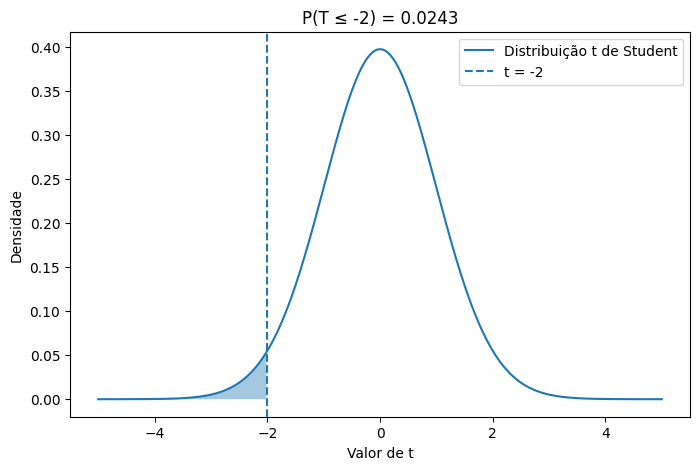

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 500)

y = stats.t.pdf(x, df=graus_liberdade)

limite = -2

x_sombra = x[x <= limite]
y_sombra = stats.t.pdf(x_sombra, df=graus_liberdade)

plt.figure(figsize=(8,5))

plt.plot(
    x, y,
    label="Distribuição t de Student"
)

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="t = -2"
)

plt.xlabel("Valor de t")
plt.ylabel("Densidade")
plt.title(f"P(T ≤ -2) = {prob_acumulada_t:.4f}")

plt.legend()
plt.show()

O resultado obtido foi P(T ≤ −2) = 0,0243, correspondendo a aproximadamente 2,43%. No gráfico, a área sombreada à esquerda de t = −2 representa exatamente essa probabilidade. Portanto, a área visualizada sob a curva corresponde ao valor calculado numericamente pelo **cdf**.

No contexto da comparação entre as espécies, valores de t negativos representam uma média da *Iris setosa* menor que a média da *Iris versicolor*. O valor observado foi ainda mais extremo, t = −10,521, estando muito além de −2.

####5.2.2 Probabilidade entre dois valores

**Pergunta biológica:** Qual é a probabilidade de a estatística t estar entre -2 e 2 quando não existe diferença real entre as médias?

In [ ]:
limite_inferior = -2
limite_superior = 2

prob_intervalo_t = (
    stats.t.cdf(limite_superior, df=graus_liberdade)
    -
    stats.t.cdf(limite_inferior, df=graus_liberdade)
)

print(f"P(-2 < T < 2) = {prob_intervalo_t:.4f}")
print(f"Probabilidade = {prob_intervalo_t*100:.2f}%")

P(-2 < T < 2) = 0.9514
Probabilidade = 95.14%


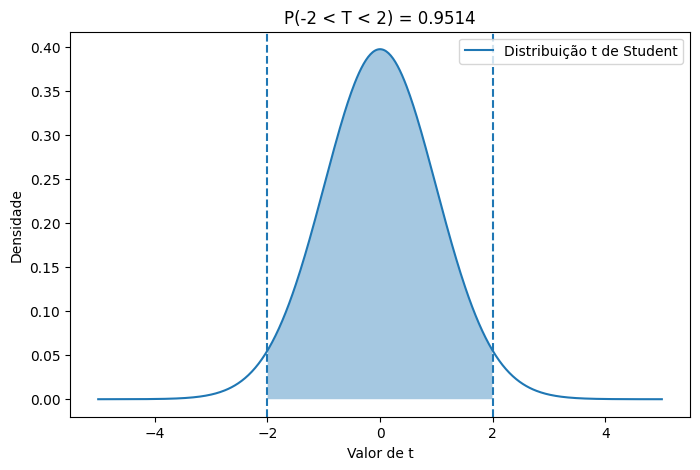

In [ ]:
x = np.linspace(-5, 5, 500)

y = stats.t.pdf(x, df=graus_liberdade)

x_sombra = x[
    (x >= limite_inferior) &
    (x <= limite_superior)
]

y_sombra = stats.t.pdf(
    x_sombra,
    df=graus_liberdade
)

plt.figure(figsize=(8,5))

plt.plot(
    x, y,
    label="Distribuição t de Student"
)

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite_inferior,
    linestyle="--"
)

plt.axvline(
    limite_superior,
    linestyle="--"
)

plt.xlabel("Valor de t")
plt.ylabel("Densidade")
plt.title(f"P(-2 < T < 2) = {prob_intervalo_t:.4f}")

plt.legend()
plt.show()

O resultado foi P(−2 < T < 2) = 0,9514, ou aproximadamente 95,14%. A área sombreada entre t = −2 e t = 2 representa visualmente esses 95,14% da distribuição. Dessa forma, o resultado numérico calculado pela diferença entre as funções **cdf** corresponde à área central observada no gráfico.

Essa região representa os valores de t mais próximos de zero, ou seja, diferenças entre médias que, quando padronizadas pelo erro-padrão, não são tão extremas quanto valores localizados nas caudas.


####5.2.3 Probabilidade acima de um valor

**Pergunta biológica:** Qual é a probabilidade de obter um valor de t maior que 2?

In [ ]:
limite = 2

prob_acima_t = stats.t.sf(
    limite,
    df=graus_liberdade
)

print(f"P(T > 2) = {prob_acima_t:.4f}")
print(f"Probabilidade = {prob_acima_t*100:.2f}%")

P(T > 2) = 0.0243
Probabilidade = 2.43%


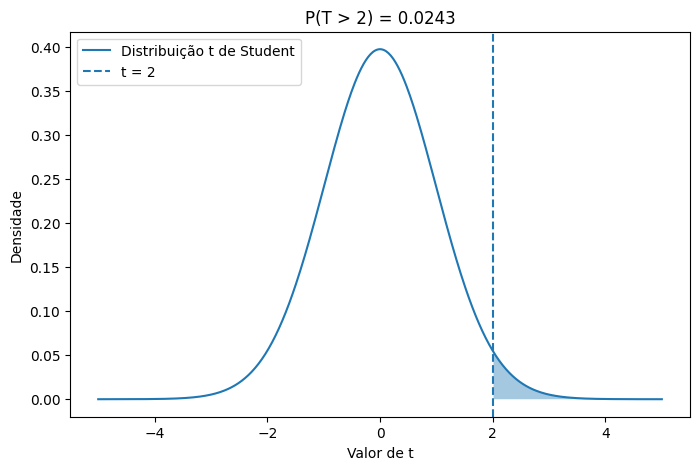

In [ ]:
x = np.linspace(-5, 5, 500)

y = stats.t.pdf(
    x,
    df=graus_liberdade
)

x_sombra = x[x >= limite]
y_sombra = stats.t.pdf(
    x_sombra,
    df=graus_liberdade
)

plt.figure(figsize=(8,5))

plt.plot(
    x, y,
    label="Distribuição t de Student"
)

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="t = 2"
)

plt.xlabel("Valor de t")
plt.ylabel("Densidade")
plt.title(f"P(T > 2) = {prob_acima_t:.4f}")

plt.legend()
plt.show()

O resultado foi P(T > 2) = 0,0243, ou aproximadamente 2,43%. A área sombreada à direita de t = 2 representa essa probabilidade e corresponde à cauda superior da distribuição. Portanto, a área do gráfico representa visualmente os mesmos 2,43% calculados numericamente pela função **sf**.

Como a distribuição t é simétrica em torno de zero, a probabilidade de T > 2 é igual à probabilidade de T < −2 para os mesmos graus de liberdade.

####5.2.4 Percentil

**Pergunta biológica:** Qual é o valor correspondente ao 95º percentil da distribuição t com os graus de liberdade obtidos pelo teste de Welch?

In [ ]:
percentil_95_t = stats.t.ppf(
    0.95,
    df=graus_liberdade
)

print(f"95º percentil = {percentil_95_t:.4f}")

95º percentil = 1.6627


Ou seja, aproximadamente 95% dos valores da distribuição t estão abaixo de 1,663, enquanto os 5% restantes estão acima desse valor.

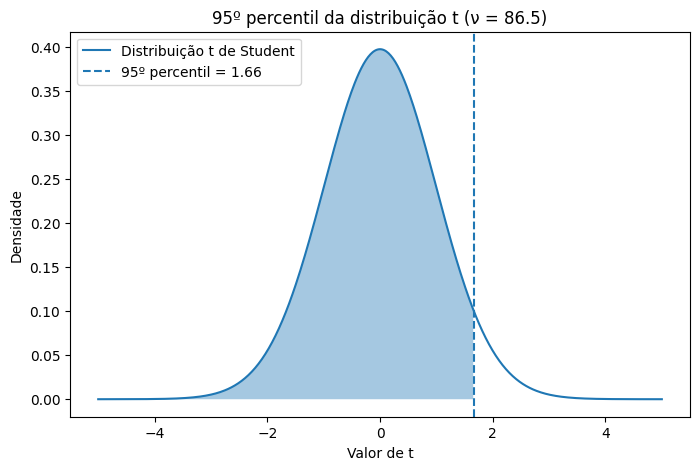

In [ ]:
x = np.linspace(-5, 5, 500)

y = stats.t.pdf(
    x,
    df=graus_liberdade
)

x_sombra = x[x <= percentil_95_t]

y_sombra = stats.t.pdf(
    x_sombra,
    df=graus_liberdade
)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    y,
    label="Distribuição t de Student"
)

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    percentil_95_t,
    linestyle="--",
    label=f"95º percentil = {percentil_95_t:.2f}"
)

plt.xlabel("Valor de t")
plt.ylabel("Densidade")
plt.title(f"95º percentil da distribuição t (ν = {graus_liberdade:.1f})")

plt.legend()
plt.show()

O 95º percentil foi 1,6627. No gráfico, a linha tracejada indica esse valor e a área sombreada à esquerda corresponde a 95% da distribuição. Os 5% restantes estão localizados à direita da linha.

Assim, o valor calculado pela função **ppf**(0.95) corresponde ao ponto da curva que separa os 95% inferiores dos 5% superiores da distribuição.

- *Iris setosa* → média = 5,006 cm
- *Iris versicolor* → média = 5,936 cm

**Diferença observada entre as médias:** 5,006 − 5,936 = −0,930 cm

**A estatística t é calculada pela diferença entre as médias dividida pelo erro-padrão da diferença:** t = (x̄₁ − x̄₂) / erro-padrão

Neste caso: t ≈ −10,52

###5.3 Probabilidades para distribuição qui-Quadrado
Vamos usar o comprimento da sépala de *Iris setosa*.

**Temos:**
- \(n=50\)
- desvio-padrão amostral ≈ 0,3525 cm
- variância amostral \(S^2\) ≈ 0,1242 cm²
- graus de liberdade: v=n−1 = 49

**Limitação:** o Iris não fornece o valor de (σ_0^2). Para não fabricar um dado, vamos trabalhar nesta etapa com a distribuição teórica do qui-quadrado com 49 graus de liberdade.

####5.3.1 Probabilidade acumulada

**Pergunta biológica:** Qual é a probabilidade de uma variável aleatória com distribuição qui-quadrado e 49 graus de liberdade assumir um valor menor ou igual a 40?

In [ ]:
graus_liberdade = 49

prob_acumulada_chi = stats.chi2.cdf(40, df=graus_liberdade)

print(f"P(χ² ≤ 40) = {prob_acumulada_chi:.4f}")
print(f"Probabilidade = {prob_acumulada_chi*100:.2f}%")

P(χ² ≤ 40) = 0.1832
Probabilidade = 18.32%


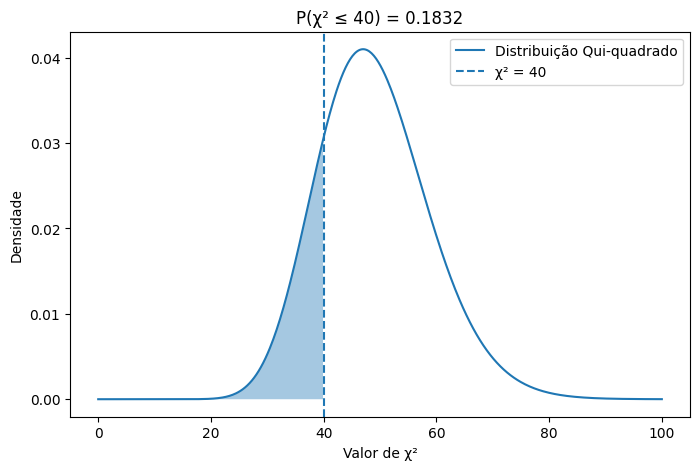

In [ ]:
x = np.linspace(0, 100, 500)
y = stats.chi2.pdf(x, df=graus_liberdade)

limite = 40

x_sombra = x[x <= limite]
y_sombra = stats.chi2.pdf(x_sombra, df=graus_liberdade)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Qui-quadrado")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="χ² = 40"
)

plt.xlabel("Valor de χ²")
plt.ylabel("Densidade")
plt.title(f"P(χ² ≤ 40) = {prob_acumulada_chi:.4f}")

plt.legend()
plt.show()

A área sombreada à esquerda de 40 corresponde a 18,32% da área total da curva. Portanto, a área visualizada no gráfico deve representar aproximadamente 18,32% da distribuição.



####5.3.2 Probabilidade entre dois valores

**Pergunta biológica:** Qual é a probabilidade de uma variável com distribuição qui-quadrado e 49 graus de liberdade assumir um valor entre 40 e 60?

In [ ]:
limite_inferior = 40
limite_superior = 60

prob_intervalo_chi = (
    stats.chi2.cdf(limite_superior, df=graus_liberdade)
    - stats.chi2.cdf(limite_inferior, df=graus_liberdade)
)

print(f"P(40 < χ² < 60) = {prob_intervalo_chi:.4f}")
print(f"Probabilidade = {prob_intervalo_chi*100:.2f}%")

P(40 < χ² < 60) = 0.6819
Probabilidade = 68.19%


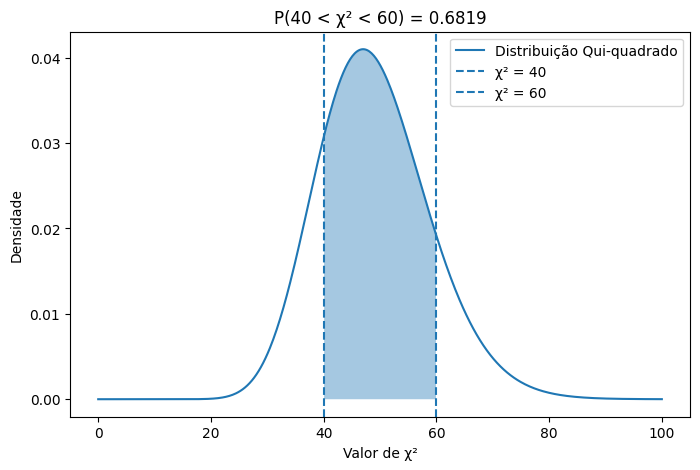

In [ ]:
x = np.linspace(0, 100, 500)
y = stats.chi2.pdf(x, df=graus_liberdade)

x_sombra = x[
    (x >= limite_inferior) &
    (x <= limite_superior)
]

y_sombra = stats.chi2.pdf(
    x_sombra,
    df=graus_liberdade
)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Qui-quadrado")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite_inferior,
    linestyle="--",
    label="χ² = 40"
)

plt.axvline(
    limite_superior,
    linestyle="--",
    label="χ² = 60"
)

plt.xlabel("Valor de χ²")
plt.ylabel("Densidade")
plt.title(f"P(40 < χ² < 60) = {prob_intervalo_chi:.4f}")

plt.legend()
plt.show()

A região sombreada entre 40 e 60 representa 68,19% da área total da curva. Ou seja, aproximadamente 68 em cada 100 valores teóricos da distribuição qui-quadrado com 49 graus de liberdade estão nesse intervalo.

####5.3.3 Probabilidade acima de um valor

**Pergunta biológica:** Qual é a probabilidade de uma variável com distribuição qui-quadrado e 49 graus de liberdade assumir um valor maior que 60?

In [ ]:
limite = 60

prob_acima_chi = stats.chi2.sf(
    limite,
    df=graus_liberdade
)

print(f"P(χ² > 60) = {prob_acima_chi:.4f}")
print(f"Probabilidade = {prob_acima_chi*100:.2f}%")

P(χ² > 60) = 0.1349
Probabilidade = 13.49%


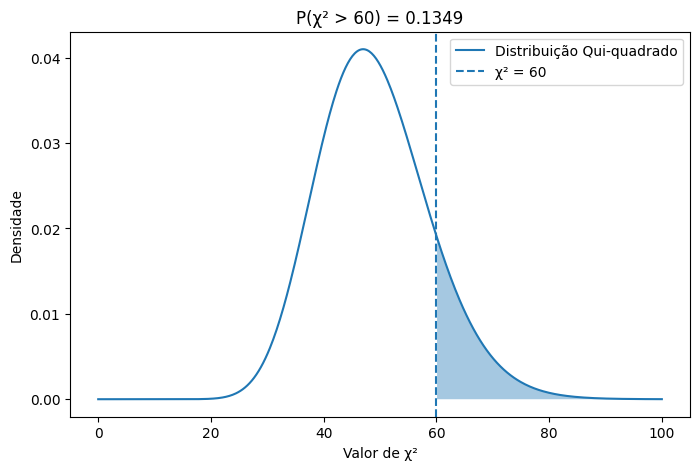

In [ ]:
x = np.linspace(0, 100, 500)
y = stats.chi2.pdf(x, df=graus_liberdade)

x_sombra = x[x >= limite]
y_sombra = stats.chi2.pdf(x_sombra, df=graus_liberdade)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Qui-quadrado")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="χ² = 60"
)

plt.xlabel("Valor de χ²")
plt.ylabel("Densidade")
plt.title(f"P(χ² > 60) = {prob_acima_chi:.4f}")

plt.legend()
plt.show()

A área sombreada à direita de 60 corresponde a 13,49% da área total da curva. Portanto, essa é a probabilidade de obter um valor superior a 60 em uma distribuição qui-quadrado com 49 graus de liberdade.

####5.3.4 Percentil

**Pergunta biológica:** Qual é o valor correspondente ao percentil 95 da distribuição qui-quadrado com 49 graus de liberdade?

In [ ]:
percentil_95_chi = stats.chi2.ppf(
    0.95,
    df=graus_liberdade
)

print(f"95º percentil = {percentil_95_chi:.4f}")

95º percentil = 66.3386


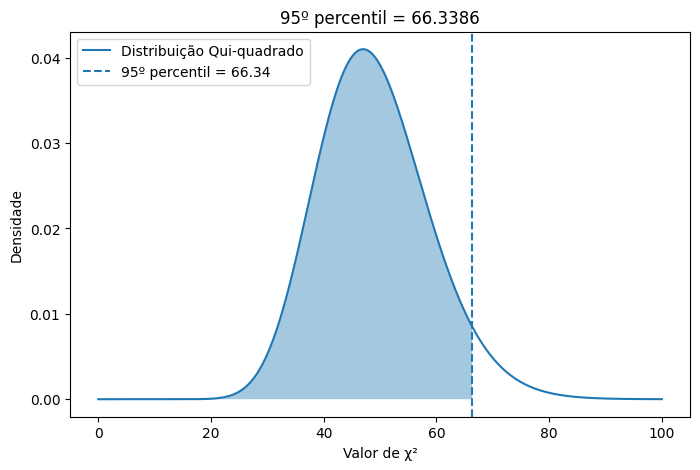

In [ ]:
x = np.linspace(0, 100, 500)
y = stats.chi2.pdf(x, df=graus_liberdade)

x_sombra = x[x <= percentil_95_chi]
y_sombra = stats.chi2.pdf(
    x_sombra,
    df=graus_liberdade
)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Qui-quadrado")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    percentil_95_chi,
    linestyle="--",
    label=f"95º percentil = {percentil_95_chi:.2f}"
)

plt.xlabel("Valor de χ²")
plt.ylabel("Densidade")
plt.title(
    f"95º percentil = {percentil_95_chi:.4f}"
)

plt.legend()
plt.show()

O valor 66,34 divide a distribuição de modo que 95% da área esteja à esquerda e 5% esteja à direita. Portanto, apenas 5% dos valores teóricos da distribuição qui-quadrado com 49 graus de liberdade são maiores que 66,34.

###5.4 Probabilidades para distribuição f de Fisher
Vamos comparar o comprimento da sépala de:
- *Iris virginica:* \(S_1^2 ≈ 0,4043\)
- *Iris setosa:* \(S_2^2 ≈ 0,1242\)

**Vamos colocar *Iris virginica* no numerador e *Iris setosa* no denominador:**

$$ F=\frac{S^2_{\text{virginica}}}{S^2_{\text{setosa}}} $$

**Como cada espécie possui 50 indivíduos:**

$$ \nu_1=50-1=49 $$ $$ \nu_2=50-1=49 $$

**A estatística observada é aproximadamente:**

$$ F=\frac{0,4043}{0,1242}\approx3,25 $$

Ou seja, a variância do comprimento da sépala em *Iris virginica* é aproximadamente 3,25 vezes a variância observada em *Iris setosa*.



####5.4.1 Probabilidade acumulada

**Pergunta biológica:** Qual é a probabilidade de uma variável aleatória com distribuição F, com 49 graus de liberdade no numerador e 49 no denominador, assumir um valor menor ou igual a 2?

In [ ]:
from scipy import stats

# Graus de liberdade
dfn = 49
dfd = 49

# Calculando a probabilidade acumulada F <= 2
prob_acumulada_f = stats.f.cdf(2, dfn=dfn, dfd=dfd)

print(f"P(F ≤ 2) = {prob_acumulada_f:.4f}")
print(f"Probabilidade = {prob_acumulada_f*100:.2f}%")

P(F ≤ 2) = 0.9916
Probabilidade = 99.16%


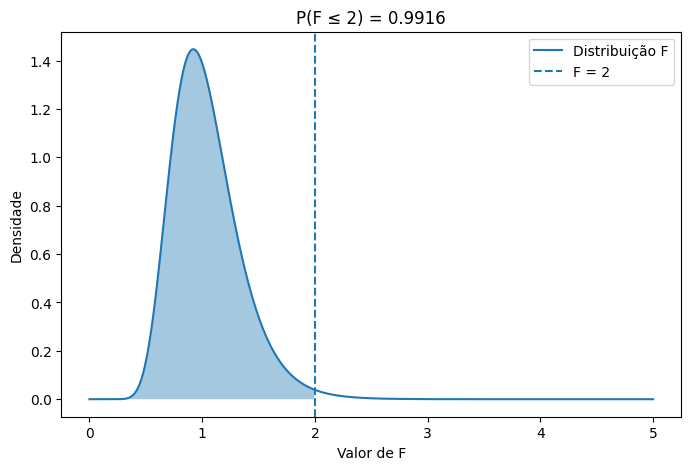

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(0, 5, 500)

y = stats.f.pdf(
    x,
    dfn=dfn,
    dfd=dfd
)

limite = 2

x_sombra = x[x <= limite]

y_sombra = stats.f.pdf(
    x_sombra,
    dfn=dfn,
    dfd=dfd
)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    y,
    label="Distribuição F"
)

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="F = 2"
)

plt.xlabel("Valor de F")
plt.ylabel("Densidade")
plt.title(f"P(F ≤ 2) = {prob_acumulada_f:.4f}")

plt.legend()
plt.show()

A área sombreada corresponde aos valores da distribuição F menores ou iguais a 2. Essa área representa aproximadamente 99,56% da área total da curva, que é exatamente o valor calculado numericamente pela função **cdf**.

####5.4.2 Probabilidade entre dois valores

**Pergunta biológica:** Qual é a probabilidade de uma variável aleatória com distribuição F ($dfn=49, dfd=49$) assumir um valor entre 0,4 e 2,0?

In [ ]:
limite_inferior = 0.4
limite_superior = 2.0

prob_intervalo_f = (
    stats.f.cdf(
        limite_superior,
        dfn=dfn,
        dfd=dfd
    )
    -
    stats.f.cdf(
        limite_inferior,
        dfn=dfn,
        dfd=dfd
    )
)

print(f"P({limite_inferior} < F < {limite_superior}) = {prob_intervalo_f:.4f}")
print(f"Probabilidade = {prob_intervalo_f*100:.2f}%")

P(0.4 < F < 2.0) = 0.9907
Probabilidade = 99.07%


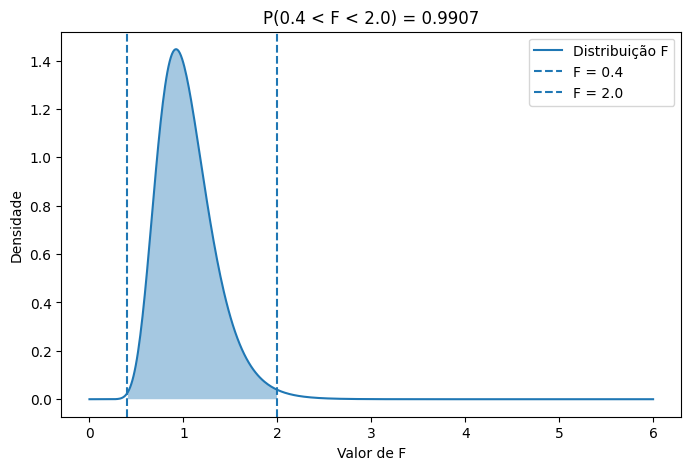

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Ajustando os limites locais para a pergunta 5.4.2 (0.4 e 2.0)
limite_inferior_grafico = 0.4
limite_superior_grafico = 2.0

x = np.linspace(0, 6, 500)
y = stats.f.pdf(x, dfn=dfn, dfd=dfd)

x_sombra = x[
    (x >= limite_inferior_grafico) &
    (x <= limite_superior_grafico)
]
y_sombra = stats.f.pdf(x_sombra, dfn=dfn, dfd=dfd)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Distribuição F")
plt.fill_between(x_sombra, y_sombra, alpha=0.4)

plt.axvline(
    limite_inferior_grafico,
    linestyle="--",
    label=f"F = {limite_inferior_grafico}"
)
plt.axvline(
    limite_superior_grafico,
    linestyle="--",
    label=f"F = {limite_superior_grafico}"
)

plt.xlabel("Valor de F")
plt.ylabel("Densidade")
plt.title(f"P({limite_inferior_grafico} < F < {limite_superior_grafico}) = {prob_intervalo_f:.4f}")
plt.legend()
plt.show()

A região sombreada entre 2 e 4 representa apenas 0,44% da área total da distribuição. Isso mostra que, para uma distribuição F com 49 e 49 graus de liberdade, valores nessa região são pouco frequentes.

####5.4.3 Probabilidade acima de um valor

**Pergunta biológica:** Qual é a probabilidade de a razão de variâncias entre as espécies ser maior do que 2,0?

In [ ]:
limite = 2.0

# Calculando a probabilidade na cauda superior (Survival Function)
prob_acima_f = stats.f.sf(limite, dfn=dfn, dfd=dfd)

print(f"P(F > {limite}) = {prob_acima_f:.4f}")
print(f"Probabilidade = {prob_acima_f*100:.2f}%")

P(F > 2.0) = 0.0084
Probabilidade = 0.84%


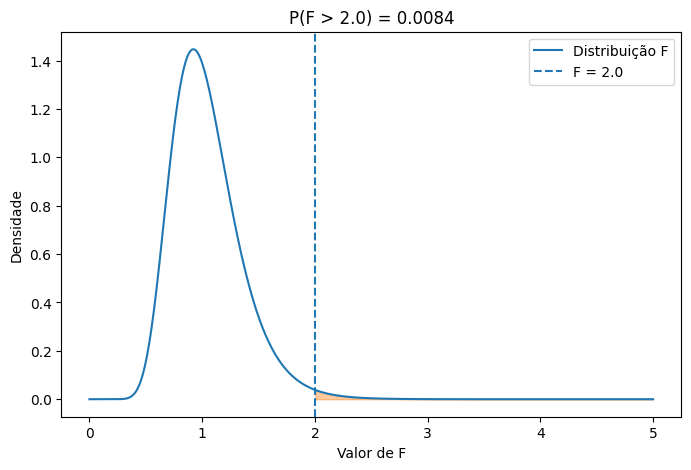

In [ ]:
x = np.linspace(0, 5, 500)
y = stats.f.pdf(x, dfn=dfn, dfd=dfd)

x_sombra = x[x >= limite]
y_sombra = stats.f.pdf(x_sombra, dfn=dfn, dfd=dfd)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Distribuição F")
plt.fill_between(x_sombra, y_sombra, alpha=0.4, color="tab:orange")
plt.axvline(limite, linestyle="--", label=f"F = {limite}")
plt.xlabel("Valor de F")
plt.ylabel("Densidade")
plt.title(f"P(F > {limite}) = {prob_acima_f:.4f}")
plt.legend()
plt.show()

A linha tracejada marca o valor observado de aproximadamente 3,25. A pequena região sombreada à direita representa a probabilidade de obter valores ainda maiores.

Essa área corresponde a aproximadamente 0,0006%, mostrando que o valor observado está muito distante da maior parte da distribuição F(49,49).

No conjunto Iris, a variância do comprimento da sépala de *Iris virginica* foi aproximadamente 3,25 vezes maior que a de *Iris setosa*. A distribuição F permite avaliar quão extremo é esse quociente de variâncias sob um modelo de referência.



####5.4.4 Percentil

**Pergunta biológica:** Qual é o valor crítico de F correspondente ao 95º percentiln para essa distribuição?

In [ ]:
# Calculando o 95º percentil (Percent Point Function)
percentil_95_f = stats.f.ppf(0.95, dfn=dfn, dfd=dfd)

print(f"95º percentil da Distribuição F = {percentil_95_f:.4f}")

95º percentil da Distribuição F = 1.6073


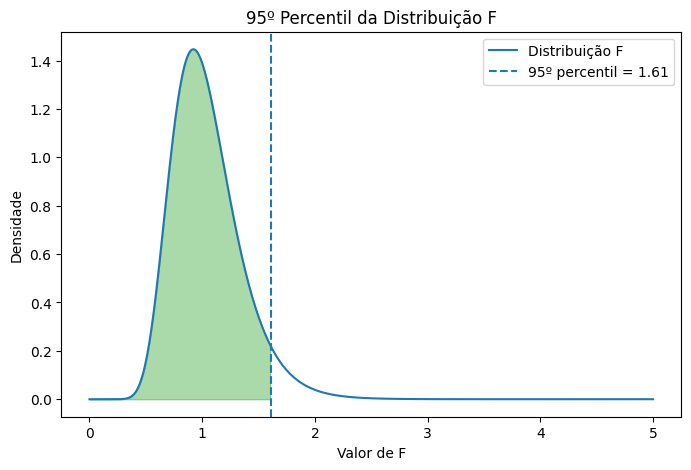

In [ ]:
x = np.linspace(0, 5, 500)
y = stats.f.pdf(x, dfn=dfn, dfd=dfd)

x_sombra = x[x <= percentil_95_f]
y_sombra = stats.f.pdf(x_sombra, dfn=dfn, dfd=dfd)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Distribuição F")
plt.fill_between(x_sombra, y_sombra, alpha=0.4, color="tab:green")
plt.axvline(percentil_95_f, linestyle="--", label=f"95º percentil = {percentil_95_f:.2f}")
plt.xlabel("Valor de F")
plt.ylabel("Densidade")
plt.title(f"95º Percentil da Distribuição F")
plt.legend()
plt.show()

O valor de 1,61 deixa 95% da área da distribuição à esquerda e os 5% restantes à direita. Portanto, apenas 5% dos valores teóricos da distribuição F(49,49) são superiores a aproximadamente 1,61.


##**Referências:**    
FISHER, R. A. *Iris*. UCI Machine Learning Repository, 1936. DOI: https://doi.org/10.24432/C56C76. Disponível em: https://archive.ics.uci.edu/dataset/53/iris. Acesso em: 6 out. 2026.         
SciPy Documentation – `scipy.stats.norm`;          
NIST/SEMATECH e-Handbook of Statistical Methods.